Total unified rows: 420
Methods: ['ADASYN', 'CTAB-GAN+', 'CTGAN_MOS', 'G-SMOTE', 'KMeans_CTGAN', 'None', 'Q-G-CTGAN', 'SMOTE', 'ctdGAN']
Datasets: 16

Rank computation functions ready.
Analysis (a): 8 methods x 12 datasets
  Datasets: ['abalone_19', 'churn', 'credit_default', 'ibm_attrition', 'mammography', 'pageblocks', 'pima_diabetes', 'satellite', 'secom', 'thyroid_sick', 'wine_quality', 'yeast_me2']
Analysis (b) [PRIMARY]: 7 methods x 16 datasets
  Datasets: ['abalone_19', 'churn', 'credit_default', 'ecoli', 'fraud_detection', 'ibm_attrition', 'mammography', 'pageblocks', 'pima_diabetes', 'protein_homo', 'satellite', 'secom', 'thyroid_sick', 'unsw_nb15', 'wine_quality', 'yeast_me2']

Table: Average rank (Analysis a: 8 methods x 12 datasets)
classifier     LGBM   MLP    RF  Overall
Q-G-CTGAN      2.67  4.42  3.67     3.58
G-SMOTE        4.42  3.08  4.17     3.89
SMOTE          4.92  4.75  3.17     4.28
K-means CTGAN  3.75  4.25  5.21     4.40
CTGAN-MOS      4.46  4.38  4.62     4.49

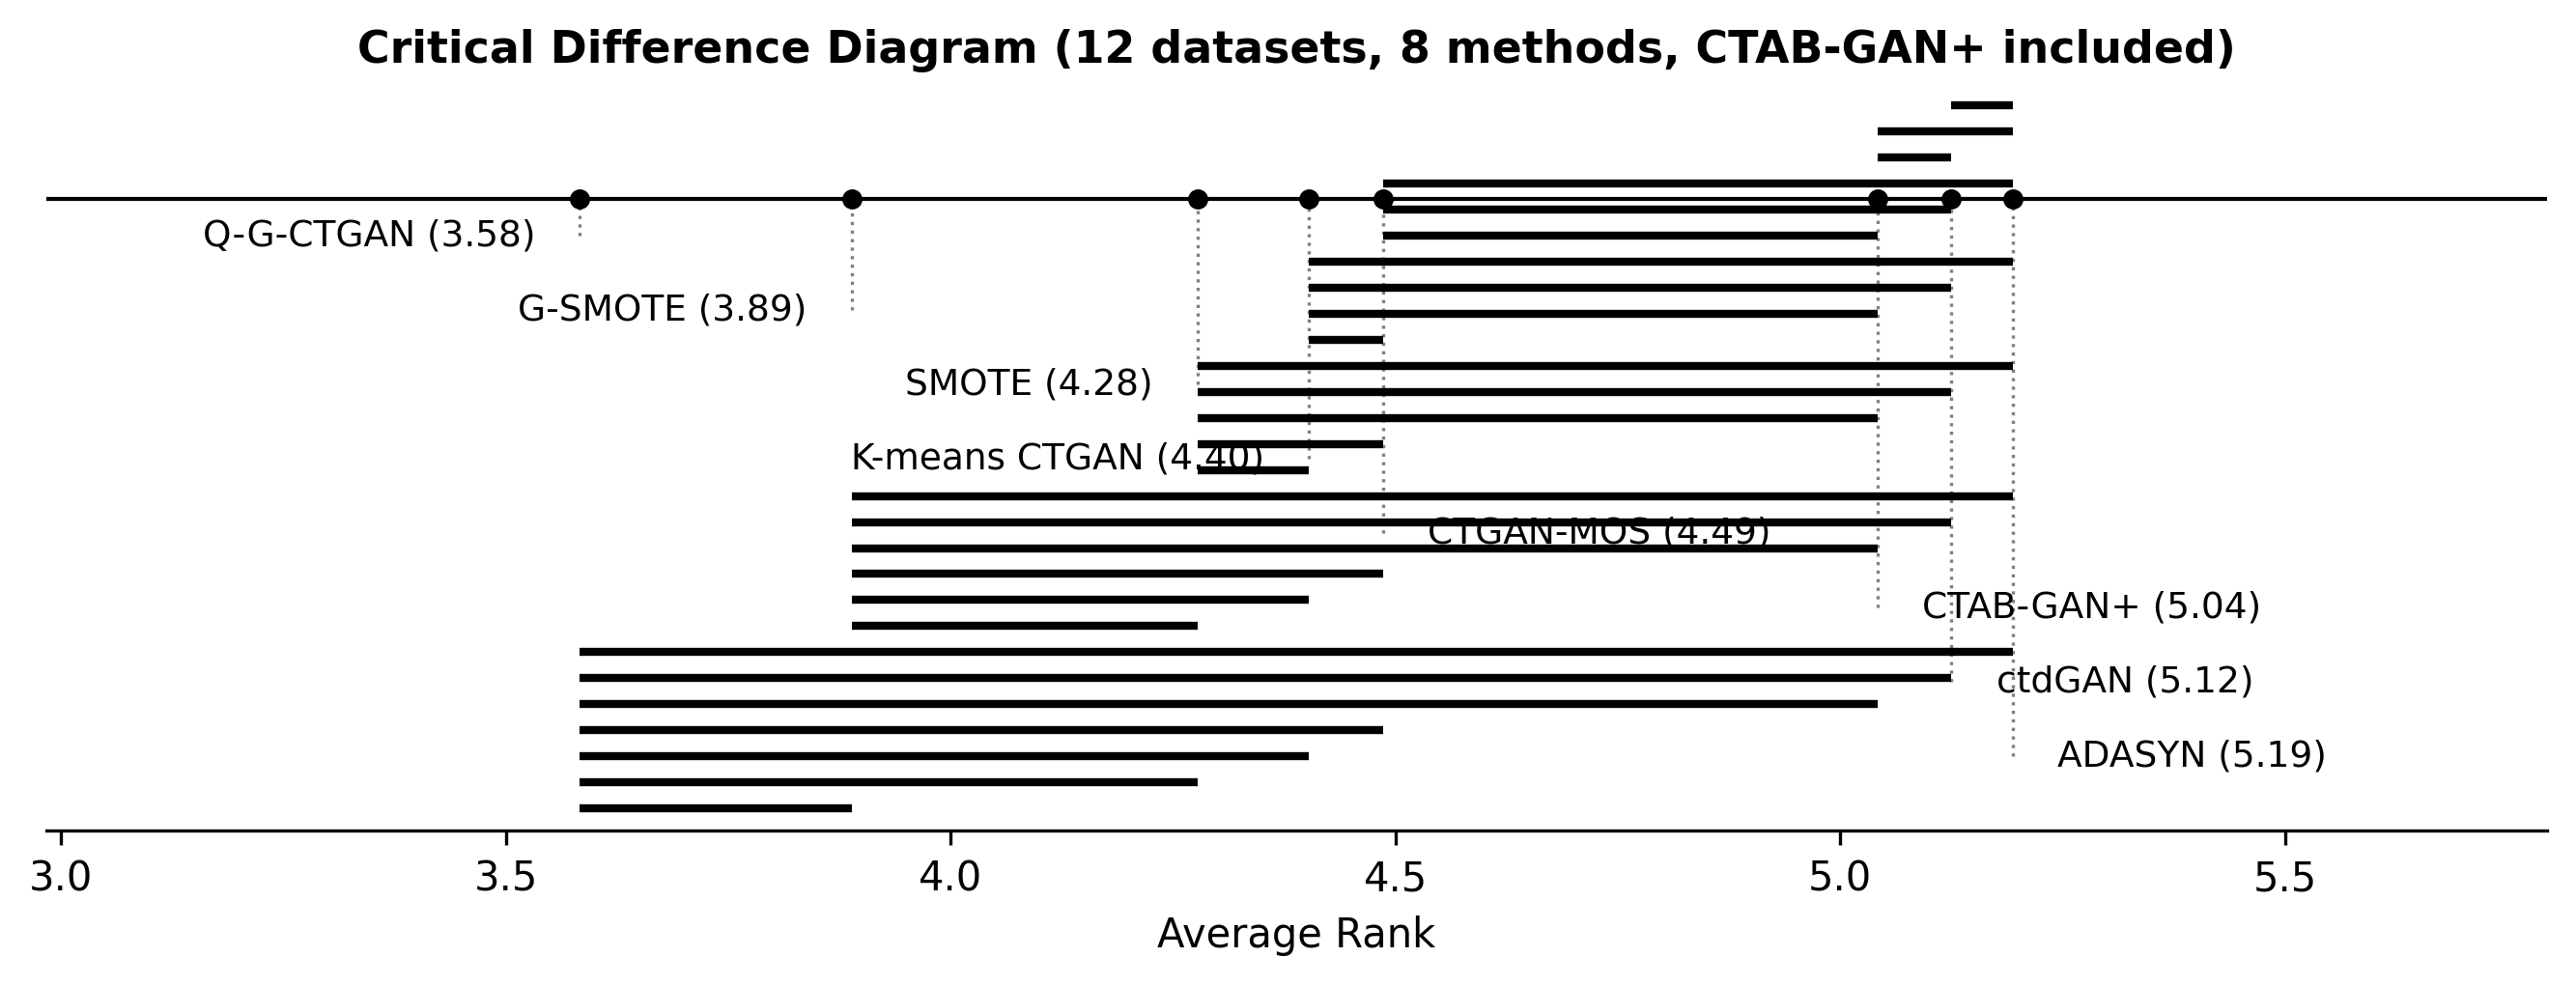

Saved: ./results\06_cd_diagram_b.png / .pdf


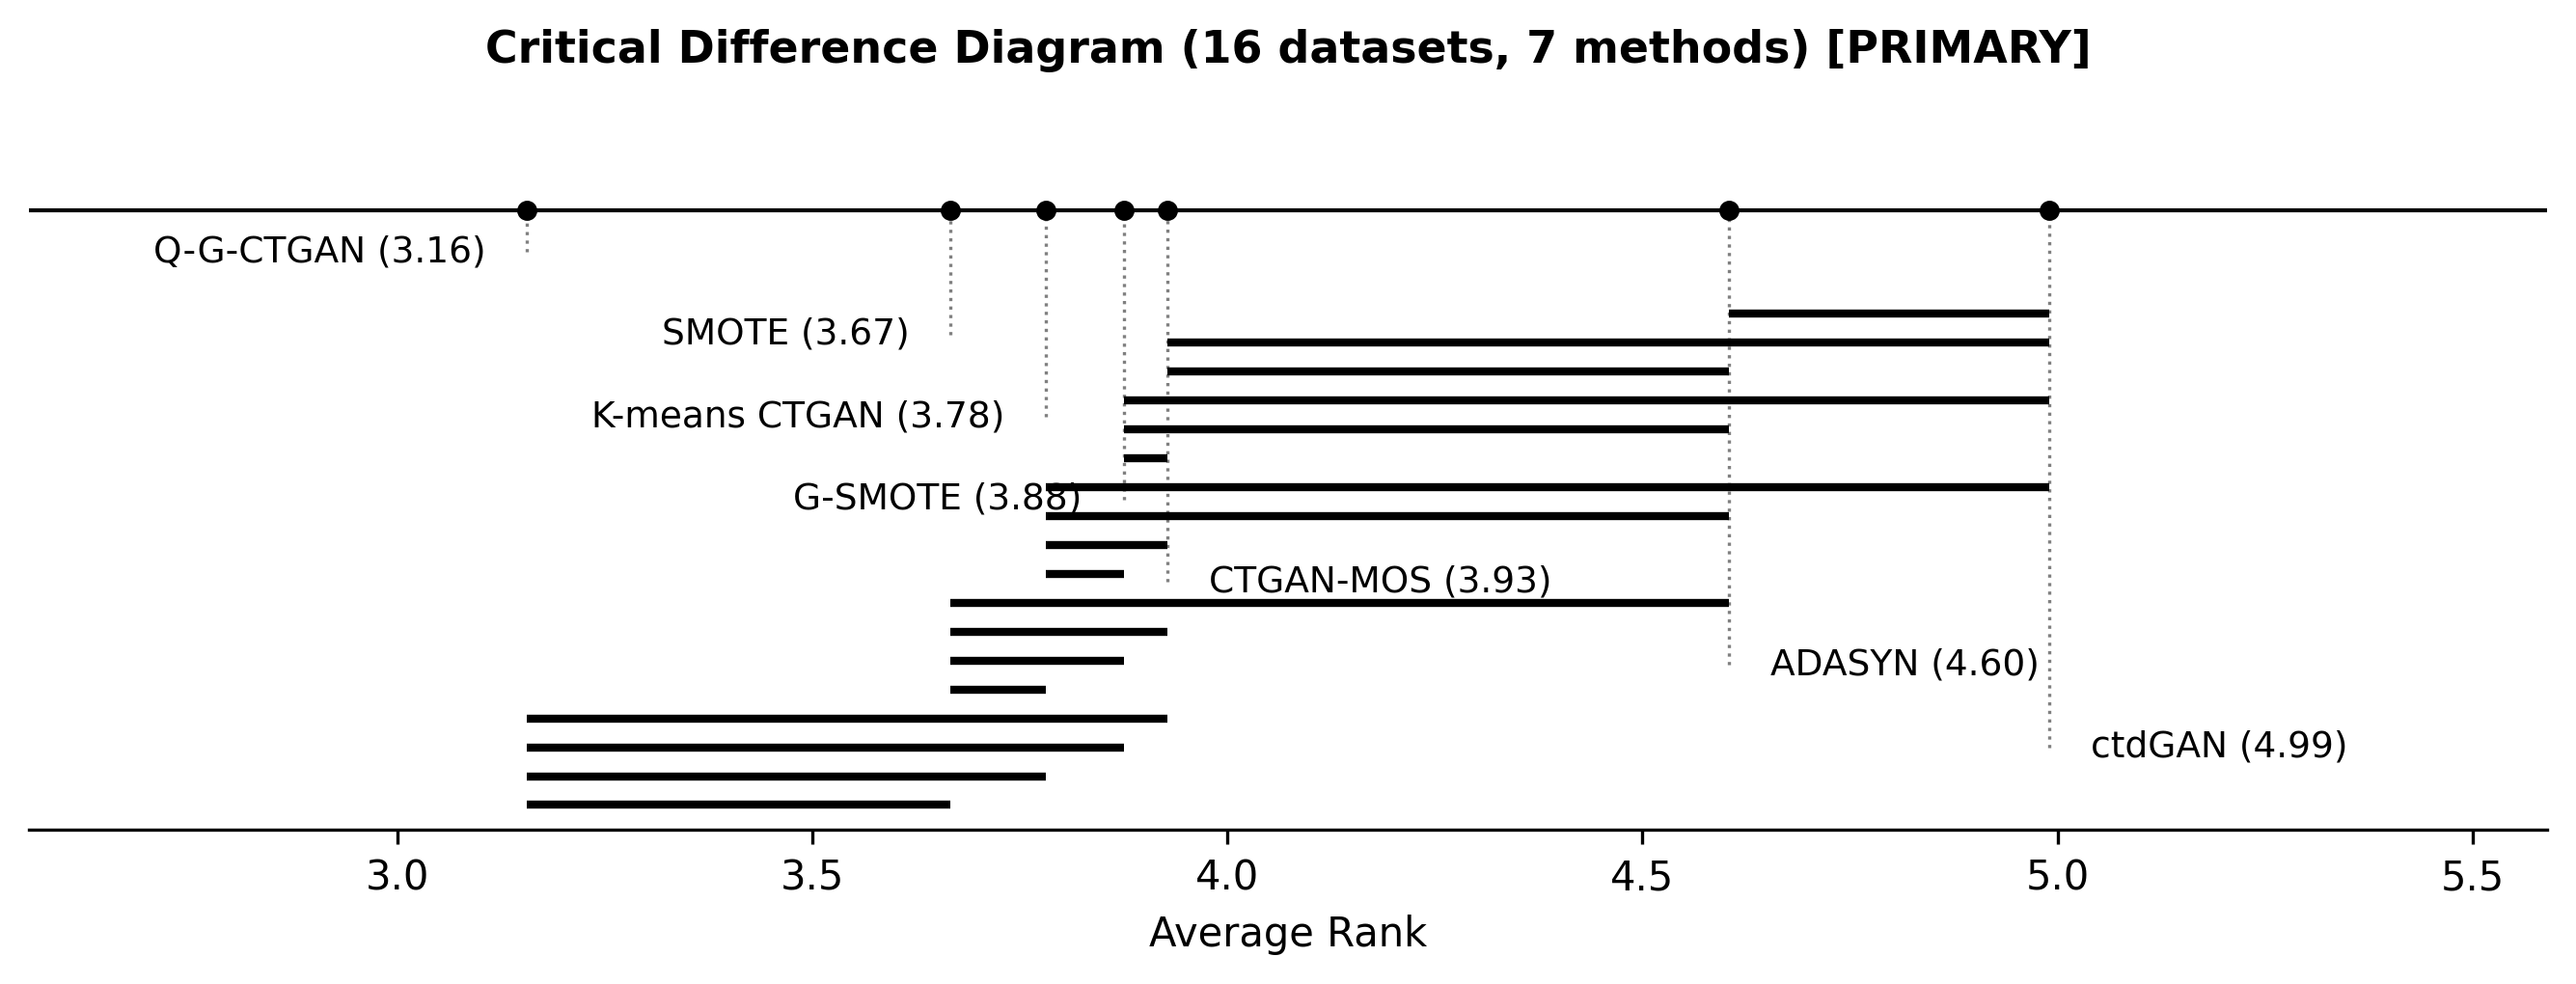


06_statistical_analysis complete.


In [8]:
"""
Q-G-CTGAN: Quality-Aware Cluster-Conditioned Oversampling
via Intra-Cluster Synthetic Sample Filtering

Notebook 06: Statistical Analysis (Friedman-Nemenyi)

Re-computes the Friedman test and Nemenyi post-hoc pairwise comparison
from the original manuscript (Section 4.3, Table 6), extended to:
  - 16 datasets (11 original + 5 added in the major revision)
  - 8 oversampling methods (3 original non-generative baselines --
    SMOTE, ADASYN, G-SMOTE -- the proposed Q-G-CTGAN, and 4 newly
    added generative baselines: K-means CTGAN, CTGAN-MOS, ctdGAN,
    CTAB-GAN+)

"None" (no oversampling) is EXCLUDED from this rank comparison, to
match the original manuscript's protocol: Table 6 in the original
manuscript compares only oversampling methods against each other, not
against the no-oversampling baseline (which does appear in Tables 3-5,
the AUC results, but not in the rank/statistical comparison).

Addresses Reviewer #1 (R1-5): the original manuscript's Friedman test
was significant but no pairwise Nemenyi comparison reached p < 0.05,
attributed to the conservatism of Nemenyi's critical difference with
only 11 datasets. This notebook tests whether the larger sample
(16 datasets) and larger comparison set (8 methods) changes this
outcome.

NOTE ON CTAB-GAN+ MISSING DATA: CTAB-GAN+ was evaluated on only 12/16
datasets (see Notebook 04c). Since the Friedman test requires a
complete block design (every method evaluated on every dataset), two
analyses are reported:
  (a) 8 methods x 12 datasets (CTAB-GAN+ included, the subset where
      all 8 methods have complete data) -- for readers interested in
      CTAB-GAN+'s standing specifically.
  (b) 7 methods x 16 datasets (CTAB-GAN+ excluded) -- the PRIMARY
      analysis, using full dataset coverage and matching the original
      manuscript's 7-method comparison most closely in spirit.

Reads  : ./results/05_unified_results.csv
Writes : ./results/06_*.csv / *.png / *.pdf
"""

import os
import numpy as np
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib as mpl

RESULTS_DIR = "./results"

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 10,
    "font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42,
})

unified = pd.read_csv(os.path.join(RESULTS_DIR, "05_unified_results.csv"), keep_default_na=False)

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "KMeans_CTGAN", "CTGAN_MOS", "ctdGAN", "CTAB-GAN+", "Q-G-CTGAN",
]
METHOD_LABELS = {
    "None": "None", "SMOTE": "SMOTE", "ADASYN": "ADASYN", "G-SMOTE": "G-SMOTE",
    "KMeans_CTGAN": "K-means CTGAN", "CTGAN_MOS": "CTGAN-MOS",
    "ctdGAN": "ctdGAN", "CTAB-GAN+": "CTAB-GAN+", "Q-G-CTGAN": "Q-G-CTGAN",
}

print(f"Total unified rows: {len(unified)}")
print(f"Methods: {sorted(unified['method'].unique())}")
print(f"Datasets: {unified['dataset'].nunique()}")


# ════════════════════════════════════════════════════════════
## 1. Rank Computation (per classifier, per dataset)
# ════════════════════════════════════════════════════════════
# For each classifier and each dataset, methods are ranked by AUC
# (rank 1 = highest AUC). Overall rank = average across RF, LGBM, MLP,
# matching the original manuscript's protocol (Section 4.3, Table 6).

def compute_ranks(df, methods, datasets, classifiers=("RF", "LGBM", "MLP")):
    """
    Returns a long-format DataFrame with one row per (dataset,
    classifier) block and one column per method (rank values), used
    as input to summarize_ranks() and for reference; the Friedman/
    Nemenyi tests use friedman_nemenyi_from_auc() below instead, which
    operates on raw AUC values directly (the statistically correct
    input for these tests).
    """
    rank_records = []
    for clf in classifiers:
        for ds in datasets:
            sub = df[(df["classifier"] == clf) & (df["dataset"] == ds)]
            sub = sub[sub["method"].isin(methods)]
            if len(sub) != len(methods):
                continue
            sub = sub.set_index("method").reindex(methods)
            if sub["AUC"].isna().any():
                continue
            ranks = sub["AUC"].rank(ascending=False, method="average")
            row = {"dataset": ds, "classifier": clf}
            row.update(ranks.to_dict())
            rank_records.append(row)
    return pd.DataFrame(rank_records)


def summarize_ranks(rank_df, methods):
    """Average rank per method per classifier, plus overall average
    (mean across the three classifiers), sorted best-to-worst."""
    per_clf = rank_df.groupby("classifier")[methods].mean().T
    per_clf["Overall"] = per_clf.mean(axis=1)
    return per_clf.sort_values("Overall")


print("\nRank computation functions ready.")


# ════════════════════════════════════════════════════════════
## 2. Define the two analyses (None excluded, per manuscript protocol)
# ════════════════════════════════════════════════════════════

ctabgan_datasets = set(unified[unified["method"] == "CTAB-GAN+"]["dataset"].unique())

# Analysis (a): 8 oversampling methods x 12 datasets (CTAB-GAN+ included)
METHODS_A = [m for m in METHOD_ORDER if m != "None"]
DATASETS_A = sorted(ctabgan_datasets)

# Analysis (b): 7 oversampling methods x 16 datasets (CTAB-GAN+ excluded, PRIMARY)
METHODS_B = [m for m in METHOD_ORDER if m not in ("None", "CTAB-GAN+")]
DATASETS_B = sorted(unified["dataset"].unique())

print(f"Analysis (a): {len(METHODS_A)} methods x {len(DATASETS_A)} datasets")
print(f"  Datasets: {DATASETS_A}")
print(f"Analysis (b) [PRIMARY]: {len(METHODS_B)} methods x {len(DATASETS_B)} datasets")
print(f"  Datasets: {DATASETS_B}")


# ════════════════════════════════════════════════════════════
## 3. Average Rank Tables
# ════════════════════════════════════════════════════════════

rank_df_a = compute_ranks(unified, METHODS_A, DATASETS_A)
summary_a = summarize_ranks(rank_df_a, METHODS_A)
summary_a_labeled = summary_a.rename(index=METHOD_LABELS)

print("\n" + "=" * 70)
print(f"Table: Average rank (Analysis a: {len(METHODS_A)} methods x {len(DATASETS_A)} datasets)")
print("=" * 70)
print(summary_a_labeled.round(2).to_string())

rank_df_b = compute_ranks(unified, METHODS_B, DATASETS_B)
summary_b = summarize_ranks(rank_df_b, METHODS_B)
summary_b_labeled = summary_b.rename(index=METHOD_LABELS)

print("\n" + "=" * 70)
print(f"Table: Average rank (Analysis b [PRIMARY]: {len(METHODS_B)} methods x {len(DATASETS_B)} datasets)")
print("=" * 70)
print(summary_b_labeled.round(2).to_string())

summary_a_labeled.round(2).to_csv(os.path.join(RESULTS_DIR, "06_avg_ranks_a.csv"))
summary_b_labeled.round(2).to_csv(os.path.join(RESULTS_DIR, "06_avg_ranks_b.csv"))


# ════════════════════════════════════════════════════════════
## 4. Friedman Test + Nemenyi Post-hoc
# ════════════════════════════════════════════════════════════

def friedman_nemenyi_from_auc(df, methods, datasets, classifiers=("RF", "LGBM", "MLP"), label=""):
    """
    Builds a (n_blocks x n_methods) matrix of raw AUC values, where
    each block is a (dataset, classifier) pair, then runs the Friedman
    test and Nemenyi post-hoc test. Friedman/Nemenyi operate on raw
    scores (not pre-computed ranks); scipy/scikit-posthocs handle the
    internal ranking correctly.
    """
    blocks = []
    for clf in classifiers:
        for ds in datasets:
            sub = df[(df["classifier"] == clf) & (df["dataset"] == ds)]
            sub = sub[sub["method"].isin(methods)].set_index("method").reindex(methods)
            if sub["AUC"].isna().any():
                continue
            blocks.append(sub["AUC"].values)

    block_matrix = np.array(blocks)
    print(f"\n{label}")
    print(f"Block matrix shape: {block_matrix.shape} "
          f"({block_matrix.shape[0]} blocks x {block_matrix.shape[1]} methods)")

    stat, p_value = stats.friedmanchisquare(*[block_matrix[:, i] for i in range(block_matrix.shape[1])])
    print(f"Friedman chi-square = {stat:.4f}, p-value = {p_value:.6f}")
    print(f"Null hypothesis (equal performance) is "
          f"{'REJECTED' if p_value < 0.05 else 'NOT rejected'} at alpha=0.05")

    block_df = pd.DataFrame(block_matrix, columns=methods)
    nemenyi_result = sp.posthoc_nemenyi_friedman(block_df.values)
    nemenyi_result.columns = methods
    nemenyi_result.index = methods

    print(f"\nNemenyi post-hoc pairwise p-values:")
    print(nemenyi_result.round(4).to_string())

    return stat, p_value, nemenyi_result


def count_significant_pairs(nemenyi_result, alpha=0.05):
    """Correctly counts unique significant pairs from a symmetric
    p-value matrix, explicitly excluding the diagonal."""
    mask = (nemenyi_result.values < alpha)
    np.fill_diagonal(mask, False)
    return int(mask.sum() // 2)


def list_significant_pairs(nemenyi_result, methods, avg_ranks, alpha=0.05):
    """Lists significant pairs with p-values and the winning method
    (lower average rank = better)."""
    pairs = []
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i < j and nemenyi_result.loc[m1, m2] < alpha:
                winner = m1 if avg_ranks[m1] < avg_ranks[m2] else m2
                loser = m2 if winner == m1 else m1
                pairs.append({
                    "method_1": METHOD_LABELS.get(m1, m1),
                    "method_2": METHOD_LABELS.get(m2, m2),
                    "p_value": round(nemenyi_result.loc[m1, m2], 4),
                    "winner": METHOD_LABELS.get(winner, winner),
                    "loser": METHOD_LABELS.get(loser, loser),
                })
    return pd.DataFrame(pairs)


# Run on analysis (a)
stat_a, p_a, nemenyi_a = friedman_nemenyi_from_auc(
    unified, METHODS_A, DATASETS_A,
    label=f"Analysis (a): {len(METHODS_A)} methods x {len(DATASETS_A)} datasets (CTAB-GAN+ included)"
)
n_sig_a = count_significant_pairs(nemenyi_a)
total_pairs_a = len(METHODS_A) * (len(METHODS_A) - 1) // 2
print(f"\nSignificant pairwise comparisons (p < 0.05): {n_sig_a} / {total_pairs_a}")

sig_pairs_a = list_significant_pairs(nemenyi_a, METHODS_A, summary_a["Overall"].to_dict())
if len(sig_pairs_a) > 0:
    print(sig_pairs_a.to_string(index=False))
else:
    print("(none)")

# Run on analysis (b) -- PRIMARY
stat_b, p_b, nemenyi_b = friedman_nemenyi_from_auc(
    unified, METHODS_B, DATASETS_B,
    label=f"Analysis (b) [PRIMARY]: {len(METHODS_B)} methods x {len(DATASETS_B)} datasets (CTAB-GAN+ excluded)"
)
n_sig_b = count_significant_pairs(nemenyi_b)
total_pairs_b = len(METHODS_B) * (len(METHODS_B) - 1) // 2
print(f"\nSignificant pairwise comparisons (p < 0.05): {n_sig_b} / {total_pairs_b}")

sig_pairs_b = list_significant_pairs(nemenyi_b, METHODS_B, summary_b["Overall"].to_dict())
print(sig_pairs_b.to_string(index=False))

nemenyi_a.round(4).to_csv(os.path.join(RESULTS_DIR, "06_nemenyi_pvalues_a.csv"))
nemenyi_b.round(4).to_csv(os.path.join(RESULTS_DIR, "06_nemenyi_pvalues_b.csv"))
sig_pairs_b.to_csv(os.path.join(RESULTS_DIR, "06_significant_pairs_b.csv"), index=False)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Original manuscript (11 datasets, 7 methods): 0 significant pairwise comparisons")
print(f"Analysis (a) ({len(DATASETS_A)} datasets, {len(METHODS_A)} methods): "
      f"{n_sig_a}/{total_pairs_a} significant pairs")
print(f"Analysis (b) ({len(DATASETS_B)} datasets, {len(METHODS_B)} methods) [PRIMARY]: "
      f"{n_sig_b}/{total_pairs_b} significant pairs")


# ════════════════════════════════════════════════════════════
## 5. Critical Difference (CD) Diagram
# ════════════════════════════════════════════════════════════
# Matches the style of the original manuscript's Figures 5-7.
# Uses Analysis (b): 7 methods x 16 datasets (the primary,
# full-dataset-coverage analysis).

def plot_cd_diagram(avg_ranks, nemenyi_matrix, methods, n_datasets, alpha=0.05,
                     title="", save_path=None):
    """
    avg_ranks: dict {method: overall_avg_rank}
    nemenyi_matrix: DataFrame of pairwise p-values (methods x methods)
    Methods connected by a horizontal bar do NOT differ significantly.
    """
    sorted_methods = sorted(methods, key=lambda m: avg_ranks[m])
    n = len(sorted_methods)
    ranks_sorted = [avg_ranks[m] for m in sorted_methods]

    fig, ax = plt.subplots(figsize=(9, 3.5))

    rank_min, rank_max = min(ranks_sorted) - 0.6, max(ranks_sorted) + 0.6
    ax.set_xlim(rank_min, rank_max)
    ax.set_ylim(0, n + 2)
    ax.axhline(n + 0.5, color="black", linewidth=1)

    for i, (m, r) in enumerate(zip(sorted_methods, ranks_sorted)):
        y = n - i
        ax.plot([r, r], [y, n + 0.5], color="gray", linewidth=0.8, linestyle=":")
        ax.plot(r, n + 0.5, "o", color="black", markersize=4)
        label = METHOD_LABELS.get(m, m)
        side = "left" if i < n / 2 else "right"
        ha = "right" if side == "left" else "left"
        x_text = r - 0.05 if side == "left" else r + 0.05
        ax.text(x_text, y, f"{label} ({r:.2f})", va="center", ha=ha, fontsize=9)

    # Horizontal bars connect groups that are NOT significantly different
    bar_y = 0.3
    for i in range(n):
        for j in range(i + 1, n):
            m1, m2 = sorted_methods[i], sorted_methods[j]
            p = nemenyi_matrix.loc[m1, m2]
            if p >= alpha:
                ax.plot([ranks_sorted[i], ranks_sorted[j]], [bar_y, bar_y],
                        color="black", linewidth=2, solid_capstyle="butt")
                bar_y += 0.35

    ax.set_yticks([])
    ax.set_xlabel("Average Rank", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for spine in ["top", "left", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path + ".png", dpi=300, bbox_inches="tight")
        fig.savefig(save_path + ".pdf", bbox_inches="tight")
        print(f"Saved: {save_path}.png / .pdf")
    plt.show()


avg_ranks_a = summary_a["Overall"].to_dict()
plot_cd_diagram(
    avg_ranks_a, nemenyi_a, METHODS_A, n_datasets=len(DATASETS_A),
    title=f"Critical Difference Diagram ({len(DATASETS_A)} datasets, {len(METHODS_A)} methods, CTAB-GAN+ included)",
    save_path=os.path.join(RESULTS_DIR, "06_cd_diagram_a")
)

avg_ranks_b = summary_b["Overall"].to_dict()
plot_cd_diagram(
    avg_ranks_b, nemenyi_b, METHODS_B, n_datasets=len(DATASETS_B),
    title=f"Critical Difference Diagram ({len(DATASETS_B)} datasets, {len(METHODS_B)} methods) [PRIMARY]",
    save_path=os.path.join(RESULTS_DIR, "06_cd_diagram_b")
)

print("\n06_statistical_analysis complete.")

In [9]:
"""
Appendix B data: full Nemenyi pairwise p-value matrices for both
analyses (a: 12 datasets/8 methods, b: 16 datasets/7 methods).
"""

def matrix_to_latex(matrix, methods, labels):
    """Upper-triangle-only LaTeX table, matching the original appendix style."""
    header = " & " + " & ".join(labels[m] for m in methods[1:]) + r" \\"
    print(header)
    print(r"\midrule")
    for i, m1 in enumerate(methods):
        row_cells = []
        for j, m2 in enumerate(methods[1:], start=1):
            if j <= i:
                row_cells.append("---")
            else:
                p = matrix.loc[m1, m2]
                cell = f"{p:.4f}"
                if p < 0.05:
                    cell = f"\\textbf{{{cell}}}"
                row_cells.append(cell)
        print(f"{labels[m1]:<15} & " + " & ".join(row_cells) + r" \\")

print("=" * 80)
print("Analysis (a): 8 methods x 12 datasets")
print("=" * 80)
matrix_to_latex(nemenyi_a, METHODS_A, METHOD_LABELS)

print()
print("=" * 80)
print("Analysis (b): 7 methods x 16 datasets [PRIMARY]")
print("=" * 80)
matrix_to_latex(nemenyi_b, METHODS_B, METHOD_LABELS)

Analysis (a): 8 methods x 12 datasets
 & ADASYN & G-SMOTE & K-means CTGAN & CTGAN-MOS & ctdGAN & CTAB-GAN+ & Q-G-CTGAN \\
\midrule
SMOTE           & 0.7579 & 0.9977 & 1.0000 & 1.0000 & 0.8249 & 0.8904 & 0.9314 \\
ADASYN          & --- & 0.3153 & 0.8705 & 0.9242 & 1.0000 & 1.0000 & 0.0973 \\
G-SMOTE         & --- & --- & 0.9870 & 0.9693 & 0.3883 & 0.4840 & 0.9995 \\
K-means CTGAN   & --- & --- & --- & 1.0000 & 0.9165 & 0.9556 & 0.8487 \\
CTGAN-MOS       & --- & --- & --- & --- & 0.9556 & 0.9796 & 0.7721 \\
ctdGAN          & --- & --- & --- & --- & --- & 1.0000 & 0.1317 \\
CTAB-GAN+       & --- & --- & --- & --- & --- & --- & 0.1844 \\
Q-G-CTGAN       & --- & --- & --- & --- & --- & --- & --- \\

Analysis (b): 7 methods x 16 datasets [PRIMARY]
 & ADASYN & G-SMOTE & K-means CTGAN & CTGAN-MOS & ctdGAN & Q-G-CTGAN \\
\midrule
SMOTE           & 0.3371 & 0.9992 & 1.0000 & 0.9971 & \textbf{0.0430} & 0.9099 \\
ADASYN          & --- & 0.6472 & 0.5030 & 0.7233 & 0.9764 & \textbf{0.0177} \\
G-SMOT